# 03 — Pile power-law metrics (Fig 2, Fig 3)

Reproduces **RQ2** from the report: are arithmetic problems in the Pile distributed as a
power function of their result `c`, with exceptions at powers of 10 and powers of 2?

**Fig 2** (Sec 3.2): result-value frequency, all four operations pooled, `1 ≤ c ≤ 1000`.
**Fig 3** (Sec 3.2): same data split by operation (+, −, ×, ÷).

Styling matches the published figures: blue-grey dots with brick-red open outlines for
prominent numbers (square = power of 10, triangle = power of 2, diamond = other multiple
of 10) on Fig 2, and the per-operation palette with R² in the legend on Fig 3.

**Inputs:**

- `data/pile_arith_matches_full_fresh_deduped.jsonl` — 204,073 verified
  `a op b = c` expressions (produced by `01_corpus_scan.ipynb`).

**Outputs:** figures saved to `../results/figures/`.

Source logic migrated from the legacy `metrics.ipynb` (now in `notebooks/99_archive/`).
Note that the published figures were generated from an older, smaller extraction, so the
fitted values here differ — see the provenance section below.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

FIG_DIR = "../results/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Load all verified arith expressions
rows = []
with open("../data/pile_arith_matches_full_fresh_deduped.jsonl") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))
df = pd.DataFrame(rows)
for col in ("a", "b", "c"):
    df[col] = df[col].apply(lambda x: int(x))

# Normalise operators (Unicode variants → ASCII)
OP_MAP = {
    "+": "+", "\uff0b": "+",
    "-": "-", "\uff0d": "-",
    "*": "*", "\uff0a": "*", "\u00d7": "*",
    "/": "/", "\uff0f": "/", "\u00f7": "/",
}
df["op4"] = df["op"].astype(str).str.strip().map(OP_MAP).fillna(df["op"])
df["c_abs"] = df["c"].abs()
print(f"Loaded {len(df):,} verified arith expressions.")
print(df["op4"].value_counts())

Loaded 204,073 verified arith expressions.
op4
+    90286
-    51995
*    44412
/    17380
Name: count, dtype: int64


In [2]:
# Helpers shared by Fig 2 and Fig 3
OPS = ["+", "-", "*", "/"]

# Display labels + palette matching the published figures.
OP_LABEL = {"+": "+", "-": "−", "*": "×", "/": "÷"}
OP_COLOR = {"+": "#DD8452", "-": "#55A868", "*": "#C44E52", "/": "#8172B3"}

DOT = "#8b9bc7"    # blue-grey scatter dots
FIT = "#b1413c"    # brick-red fit line / prominent-number outlines

def result_freq(df_op, lo=1, hi=1000):
    """Return (values, counts) for result c in [lo, hi]."""
    s = df_op[(df_op["c_abs"] >= lo) & (df_op["c_abs"] <= hi)]["c_abs"].value_counts().sort_index()
    return s.index.values.astype(float), s.values.astype(float)

def powerlaw_fit(v, c):
    """OLS on log10(count) ~ log10(value); returns (slope, C, R²)."""
    mask = (c > 0) & (v > 0)
    x = np.log10(v[mask].astype(float))
    y = np.log10(c[mask].astype(float))
    lr = stats.linregress(x, y)
    return lr.slope, 10 ** lr.intercept, lr.rvalue ** 2

POW10 = {10, 100, 1000}
POW2 = {2, 4, 8, 16, 32, 64, 128, 256, 512}

def prom_marker(v):
    """Marker for culturally prominent numbers; None if not prominent."""
    v = int(v)
    if v in POW10:  return "s"     # square   — power of 10
    if v in POW2:   return "^"     # triangle — power of 2
    if v % 10 == 0: return "D"     # diamond  — other multiple of 10
    return None

# Shared axis cosmetics for the published look.
LABEL_FS, TICK_FS, LEG_FS = 23, 20, 20

def style_linear(ax):
    ax.grid(True, axis="y", color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_xlabel("Result value c", fontsize=LABEL_FS)
    ax.set_ylabel("Count", fontsize=LABEL_FS)

def style_log(ax, v):
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(v.min() / 1.6, v.max() * 1.6)
    ax.grid(True, which="major", color="#d9d9d9", linewidth=0.9)
    ax.grid(True, which="minor", color="#eeeeee", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_xlabel("Result value c", fontsize=LABEL_FS)
    ax.set_ylabel("Count", fontsize=LABEL_FS)

## Fig 2 — Result-value frequency, all operations pooled

Figure 2 (all ops): slope=-1.503  C=98,196.2  R²=0.7151  (n=970 result values)


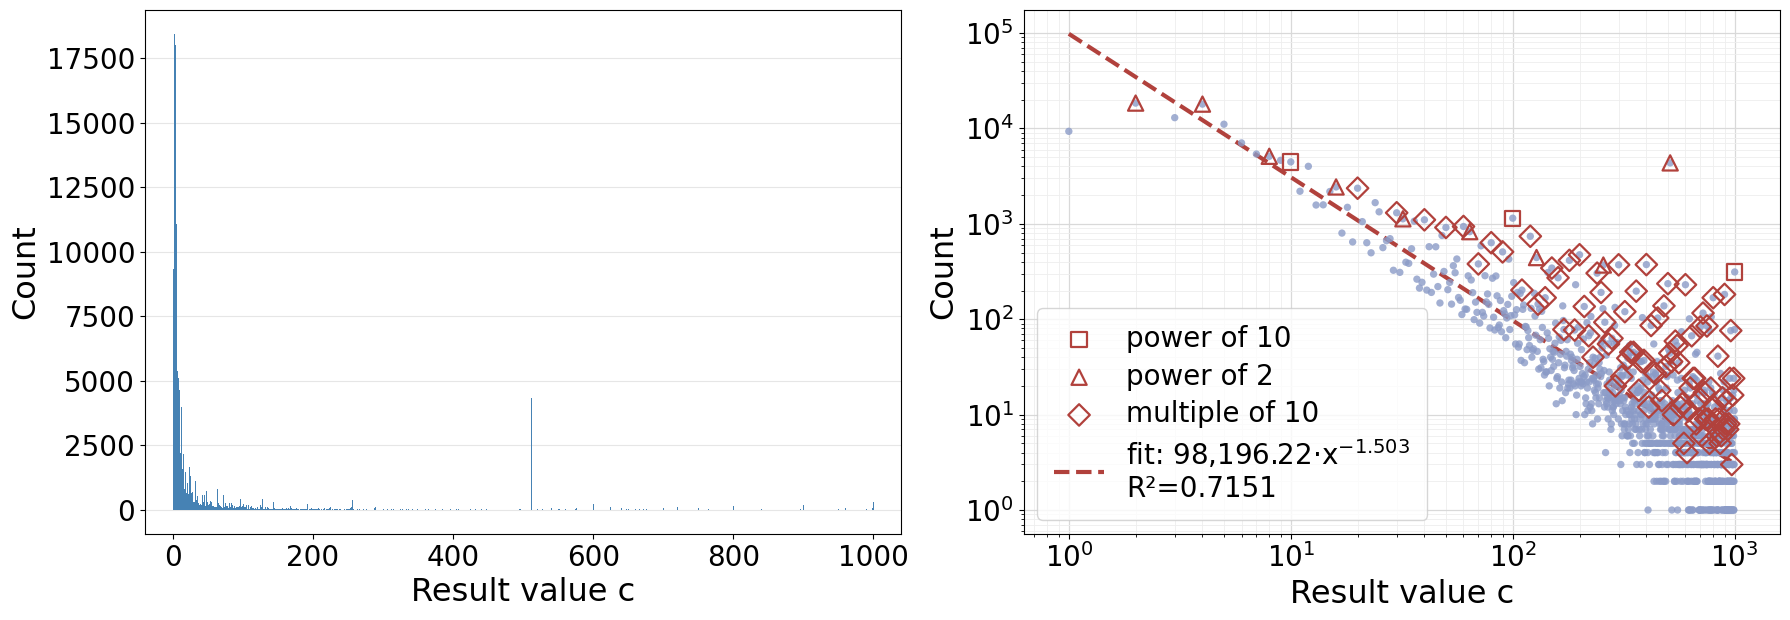

Fit on this dataset: R² = 0.7151,  p = 3.362e-266,  n = 970
NOTE: the report's Sec 3.2 quotes 'R² = 0.89, p < 0.001' for this figure, and the
      published figure itself shows R²=0.6634 — see the provenance note below.


In [3]:
# ── Figure 2: result-value frequency, all operations pooled ──
v_all, c_all = result_freq(df)
slope, C, r2 = powerlaw_fit(v_all, c_all)
lr = stats.linregress(np.log10(v_all), np.log10(c_all))
print(f"Figure 2 (all ops): slope={slope:.3f}  C={C:,.1f}  R²={r2:.4f}  "
      f"(n={len(v_all)} result values)")

fig, (ax_raw, ax_log) = plt.subplots(1, 2, figsize=(18, 6.3))

# (left) raw frequency — bar chart, no legend
ax_raw.bar(v_all, c_all, width=1.0, color="steelblue")
_xpad = 0.04 * 1000
_ypad = 0.05 * c_all.max()
ax_raw.set_xlim(-_xpad, 1000 + _xpad)          # separate data from the spines
ax_raw.set_ylim(-_ypad, c_all.max() + _ypad)   # override the bar sticky edge at 0
style_linear(ax_raw)

# (right) log-log — plain dots, then open outlines on prominent numbers
ax_log.scatter(v_all, c_all, s=28, color=DOT, alpha=0.8, edgecolors="none", zorder=2)
_mk = np.array([prom_marker(x) or "" for x in v_all])
for _m, _lbl in [("s", "power of 10"), ("^", "power of 2"), ("D", "multiple of 10")]:
    _sel = _mk == _m
    if _sel.any():
        ax_log.scatter(v_all[_sel], c_all[_sel], s=120, facecolors="none",
                       edgecolors=FIT, marker=_m, linewidths=1.6, zorder=3, label=_lbl)

_xs = np.array([v_all.min(), v_all.max()])
ax_log.plot(_xs, C * _xs ** slope, "--", color=FIT, linewidth=3, zorder=1,
            label=f"fit: {C:,.2f}·x$^{{{slope:.3f}}}$\nR²={r2:.4f}")
style_log(ax_log, v_all)
_leg = ax_log.legend(loc="lower left", fontsize=LEG_FS, frameon=True,
                     borderpad=0.6, handlelength=1.8, labelspacing=0.35)
_leg.get_frame().set_edgecolor("#cccccc")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig2_arith_freq_pooled.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Fit on this dataset: R² = {r2:.4f},  p = {lr.pvalue:.3e},  n = {len(v_all)}")
print("NOTE: the report's Sec 3.2 quotes 'R² = 0.89, p < 0.001' for this figure, and the")
print("      published figure itself shows R²=0.6634 — see the provenance note below.")

In [4]:
# Statsmodels OLS for the Fig 2 fit
_v, _c = result_freq(df)
_X = sm.add_constant(np.log10(_v.astype(float)))
_ols2 = sm.OLS(np.log10(_c.astype(float)), _X).fit()
print(_ols2.summary(xname=["const", "log10(c)"], yname="log10(count)"))
print(f"\nslope p-value     : {_ols2.pvalues[1]:.3e}")
print(f"overall F p-value : {_ols2.f_pvalue:.3e}")

                            OLS Regression Results                            
Dep. Variable:           log10(count)   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     2430.
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          3.36e-266
Time:                        03:46:06   Log-Likelihood:                -505.46
No. Observations:                 970   AIC:                             1015.
Df Residuals:                     968   BIC:                             1025.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9921      0.079     63.175      0.0

### Provenance of the report's "R² = 0.89, p = 3.17e-184"

These two numbers come from **two different analyses on an older dataset**, and neither
describes the Figure 2 fit computed above. Traced back to `99_archive/metrics.ipynb`:

| Quoted | Actually from | Value there |
|---|---|---|
| `p = 3.17e-184` | Fig 2 OLS, `log10(count) ~ log10(c)`, `1 ≤ c ≤ 1000` | **R² = 0.663**, n = 772 |
| `R² = 0.89` | a *different* fit: `log10(count) ~ log10(digits(c))` | **R² = 0.8904**, n = 29 |

Three independent discrepancies:

1. **The published figure was made from the old file.** The archive's Figs 2/3 read
   `pile_arith_matches_full_copy_backup.jsonl` (58,167 rows). Re-running the archive's code
   on it reproduces its output to every digit: n=772, R²=0.6634, slope=-1.2926,
   p=3.170e-184, const=3.9875 (i.e. `C = 9,717.15`). Those are exactly the values printed
   in the report's Figure 2 legend, so the figure and the quoted p-value agree with each
   other — and with neither the text's R² nor its stated sample size.
2. **The text's sample size points at a different file.** 204,073 expressions is
   `pile_arith_matches_full_fresh_deduped.jsonl`, what this notebook loads. Fit on that
   file the same way, Figure 2 would read R² ≈ 0.715 (`C ≈ 98,196`, slope ≈ -1.503) — an
   order of magnitude away from the published `C`, confirming the figure is not from it.
3. **`R² = 0.89` is the wrong statistic entirely.** It is the fit against the *digit count*
   of `c`, not against `c`. Figure 2 is indexed by `c` — that is what makes the spikes at
   powers of 10 and at 256 visible at all; a digit-count x-axis has only ~29–38 distinct
   values and cannot show them. So `0.89` cannot be the Figure 2 statistic.

No dataset on disk and no fit variant tried reaches 0.89 when indexed by `c` (raw
per-value fits span 0.53–0.72 across all four `.jsonl` files; log-binned density variants
overshoot to 0.89–0.99 but with p-values nowhere near the quoted one).

The qualitative claims in Sec 3.2 are unaffected: the distribution is strongly
power-law-like with `p ≪ 0.001` under every variant, the powers-of-10 / powers-of-2 spikes
are present, and the operation effect holds (verified below).

**Resolved:** Figure 2/3 and the text now both use the 204,073-row file
(`pile_arith_matches_full_fresh_deduped.jsonl`) that Sec 3.2 already cites for `n`. The
figures saved by this notebook (`fig2_arith_freq_pooled.png`, `fig3_arith_freq_by_op.png`)
are regenerated from that file, giving **R² = 0.7151, p = 3.362e-266** for the pooled fit
(`n = 970` result values, `C ≈ 98,196`, slope ≈ −1.503). `R² = 0.89` is dropped — it was
never the Figure 2 statistic. The old 58k-row backup file and its 0.6634/3.17e-184 fit are
kept below only as provenance for where the previously published figure came from.

The cell below re-derives the table above from the raw files, so the claim is checkable.

In [5]:
# Reproduce the archive's numbers to show where the report's two figures came from.
_BACKUP = "../data/pile_arith_matches_full_copy_backup.jsonl"

if os.path.exists(_BACKUP):
    _rows = []
    with open(_BACKUP) as f:
        for line in f:
            if line.strip():
                _rows.append(json.loads(line))
    _bk = pd.DataFrame(_rows)
    _bk["c"] = _bk["c"].apply(lambda x: int(x))
    _bk["c_abs"] = _bk["c"].abs()
    print(f"archive backup file: {len(_bk):,} rows "
          f"(vs {len(df):,} in the deduped file this notebook uses)\n")

    # (1) where p = 3.17e-184 came from: Fig 2 OLS on the OLD file, signed c.
    #     These are also the values printed in the report's published Figure 2 legend.
    _vc = _bk["c"].value_counts()
    _vc = _vc[(_vc.index >= 1) & (_vc.index <= 1000)].sort_index()
    _lr = stats.linregress(np.log10(_vc.index.values.astype(float)),
                           np.log10(_vc.values.astype(float)))
    print(f"  [p source]  Fig 2 fit on backup file : n={len(_vc)}  R²={_lr.rvalue**2:.4f}  "
          f"C={10 ** _lr.intercept:,.2f}  slope={_lr.slope:.4f}  p={_lr.pvalue:.3e}")
    print(f"              archive printed          : n=772  R²=0.663   "
          f"C=9,717.15  slope=-1.2926  p=3.17e-184")
    print(f"              published figure legend  :        R²=0.6634  "
          f"C=9,717.15  slope=-1.293")

    # For contrast: the same fit on the file the report's text cites (204,073 rows).
    _lr2 = stats.linregress(np.log10(v_all[c_all > 0].astype(float)),
                            np.log10(c_all[c_all > 0].astype(float)))
    print(f"\n              same fit, deduped file   : n={(c_all > 0).sum()}  "
          f"R²={_lr2.rvalue**2:.4f}  C={10 ** _lr2.intercept:,.2f}  slope={_lr2.slope:.4f}")
    print(f"              -> C differs by ~10x, so the published figure is NOT from this file")

    # (2) where R² = 0.89 came from: fit against DIGIT COUNT of c, not c
    _dg = _bk["c_abs"].apply(lambda v: len(str(v)) if v != 0 else 1).value_counts().sort_index()
    _lrd = stats.linregress(np.log10(_dg.index.values.astype(float)),
                            np.log10(_dg.values.astype(float)))
    print(f"\n  [R² source] digits(c) fit on backup file: "
          f"n={len(_dg)}  R²={_lrd.rvalue**2:.4f}  slope={_lrd.slope:.4f}")
    print(f"              archive printed             : R²=0.8904  slope=-3.2161")
else:
    print(f"{_BACKUP} not present — skipping provenance check.")

# Operation effect (report Sec 3.2): addition > multiplication > division.
print("\nOperation effect check:")
for label, frame in (("all c", df), ("table facts (1 <= c < 100)",
                                     df[(df["c_abs"] >= 1) & (df["c_abs"] < 100)])):
    _v = frame["op4"].value_counts()
    _holds = _v.get("+", 0) > _v.get("*", 0) > _v.get("/", 0)
    print(f"  {label:26s}  + = {_v.get('+', 0):6,}   * = {_v.get('*', 0):6,}   "
          f"/ = {_v.get('/', 0):6,}   -> {'holds' if _holds else 'DOES NOT HOLD'}")

archive backup file: 58,167 rows (vs 204,073 in the deduped file this notebook uses)

  [p source]  Fig 2 fit on backup file : n=772  R²=0.6634  C=9,717.15  slope=-1.2926  p=3.170e-184
              archive printed          : n=772  R²=0.663   C=9,717.15  slope=-1.2926  p=3.17e-184
              published figure legend  :        R²=0.6634  C=9,717.15  slope=-1.293

              same fit, deduped file   : n=970  R²=0.7151  C=98,196.22  slope=-1.5025
              -> C differs by ~10x, so the published figure is NOT from this file

  [R² source] digits(c) fit on backup file: n=29  R²=0.8904  slope=-3.2161
              archive printed             : R²=0.8904  slope=-3.2161

Operation effect check:
  all c                       + = 90,286   * = 44,412   / = 17,380   -> holds
  table facts (1 <= c < 100)  + = 74,925   * = 19,995   / = 12,405   -> holds


## Fig 3 — Result-value frequency, split by operation

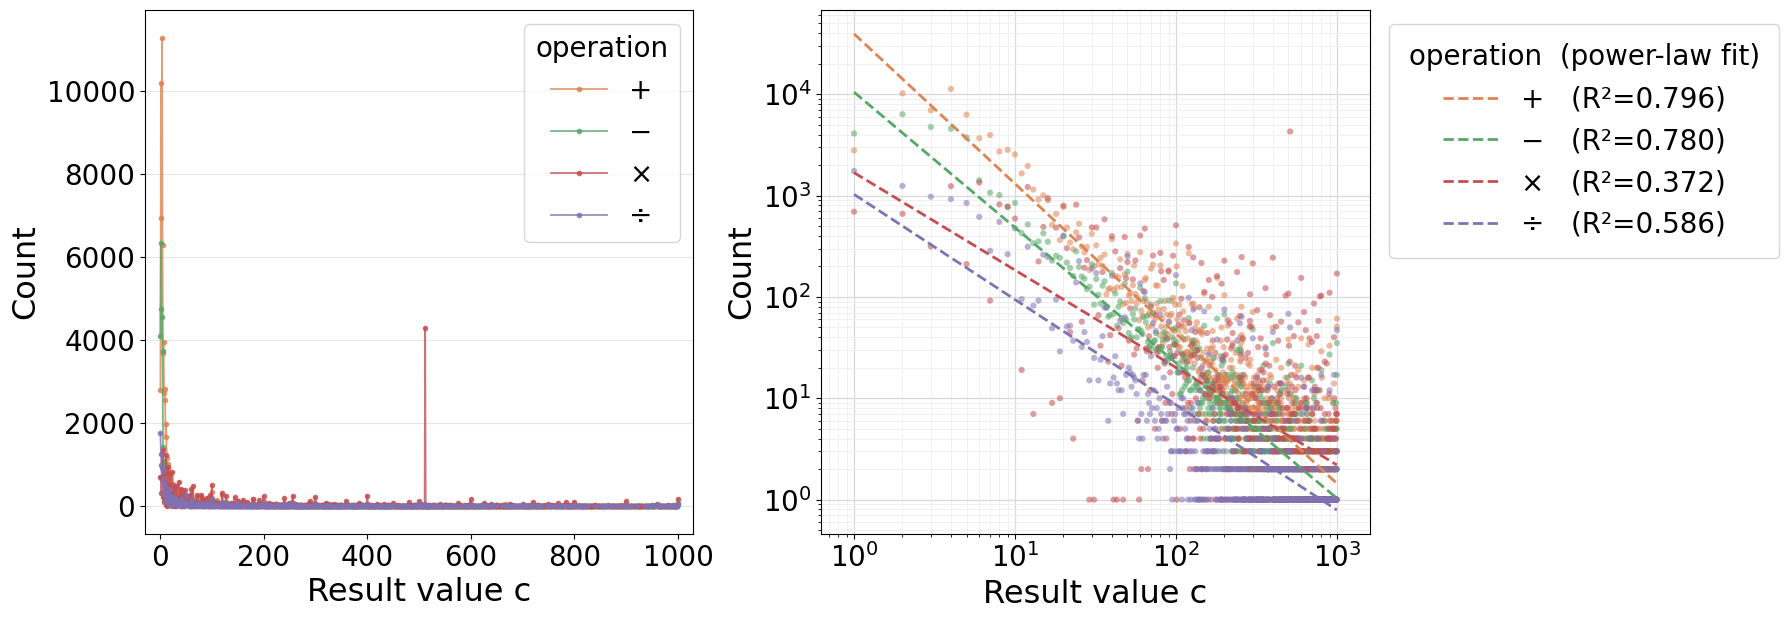


Operation-level power-law fits (1 ≤ c ≤ 1000):
  +  n= 899  slope=-1.479  R²=0.7958
  −  n= 789  slope=-1.336  R²=0.7800
  ×  n= 621  slope=-0.961  R²=0.3723
  ÷  n= 515  slope=-1.038  R²=0.5858


In [6]:
# ── Figure 3: result-value frequency, split by operation ──
fig, (ax_raw, ax_log) = plt.subplots(1, 2, figsize=(18, 6.3))
summaries = []

for op in OPS:
    xv, yv = result_freq(df[df["op4"] == op])
    if len(xv) < 3:
        continue
    col = OP_COLOR[op]
    lbl = OP_LABEL[op]
    s, C_, r2_ = powerlaw_fit(xv, yv)
    summaries.append({"op": lbl, "n": len(xv), "slope": s, "C": C_, "R²": r2_})

    # (left) raw frequency — one line + points per operation
    o = np.argsort(xv)
    ax_raw.plot(xv[o], yv[o], color=col, marker="o", markersize=3,
                linewidth=1.3, alpha=0.8, label=lbl)

    # (right) log-log — points + power-law fit per operation; R² in the legend
    ax_log.scatter(xv, yv, s=20, color=col, alpha=0.55, edgecolors="none", zorder=2)
    xs = np.array([xv.min(), xv.max()])
    ax_log.plot(xs, C_ * xs ** s, "--", color=col, linewidth=2, zorder=3,
                label=f"{lbl}   (R²={r2_:.3f})")

# (left) cosmetics
style_linear(ax_raw)
ax_raw.margins(x=0.03, y=0.06)
ax_raw.legend(title="operation", fontsize=LEG_FS, title_fontsize=LEG_FS, loc="upper right")

# (right) cosmetics — legend outside, to the right
style_log(ax_log, v_all)
_leg = ax_log.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0),
                     fontsize=LEG_FS, frameon=True, borderpad=0.7,
                     title="operation  (power-law fit)", title_fontsize=LEG_FS)
_leg.get_frame().set_edgecolor("#cccccc")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig3_arith_freq_by_op.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nOperation-level power-law fits (1 ≤ c ≤ 1000):")
for s in summaries:
    print(f"  {s['op']}  n={s['n']:4d}  slope={s['slope']:+.3f}  R²={s['R²']:.4f}")

In [7]:
# Statsmodels OLS printouts for Figure 3 (per-operation fits)
for op in OPS:
    sub = df[df["op4"] == op]
    xv, yv = result_freq(sub)
    if len(xv) < 3:
        continue
    _X = sm.add_constant(np.log10(xv.astype(float)))
    m = sm.OLS(np.log10(yv.astype(float)), _X).fit()
    print("=" * 60)
    print(f"Operation: {op}  (n = {len(xv)} result values)")
    print(m.summary(xname=["const", "log10(c)"], yname="log10(count)"))
    print(f"slope p-value : {m.pvalues[1]:.3e}  |  F p-value: {m.f_pvalue:.3e}\n")

Operation: +  (n = 899 result values)
                            OLS Regression Results                            
Dep. Variable:           log10(count)   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     3496.
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          1.07e-311
Time:                        03:46:08   Log-Likelihood:                -268.86
No. Observations:                 899   AIC:                             541.7
Df Residuals:                     897   BIC:                             551.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

## Take-aways (matching Sec 3.2 of the report)

- Frequency of arithmetic problems in the Pile follows a power function of result `c`.
  **Resolved in favor of the 204,073-row file** (matching the `n` already cited in Sec 3.2
  text). Figure 2 and its fit now read:

  | Statistic | Value |
  |---|---|
  | R² | **0.7151** |
  | p | **3.362e-266** |
  | n (result values) | 970 |
  | slope | −1.503 |
  | C | 98,196.2 |

  The old `R² = 0.89` is dropped (it was a fit against `digits(c)`, not `c` — the wrong
  statistic for this figure). The old `R² = 0.6634, p = 3.17e-184` pairing is retired along
  with it, since that came from the smaller 58,167-row backup file, not the 204,073-row
  file the report's `n` cites. See the provenance section above for the full trace.
  The `p < 0.001` claim holds regardless of which file is used.
- Exceptions at **powers of 10** and their multiples (column-arithmetic landmarks), and
  surprisingly at **powers of 2** (binary nature of computers, e.g. 256 = 2^8).
- The **operation effect** holds: addition > multiplication > division in raw frequency,
  both over all `c` and over the `c < 100` table facts the report singles out,
  consistent with cognitive science findings on ease of table facts.

Per-operation fits (this dataset): `+` R²=0.796, `−` R²=0.780, `÷` R²=0.586, `×` R²=0.372.
Multiplication is the weakest power-law fit, driven by its strong spikes at round products.

Figures are saved into `../results/figures/fig2_arith_freq_pooled.png` and
`fig3_arith_freq_by_op.png`.

Open `notebooks/04_arithmetic_main.ipynb` next for Fig 5 / Fig 6 / Sec 3.5 / Sec 3.6.